# Evaluación 2 — Programación Científica 2026-1
### Redes que aprenden bases: ¿ayuda arrancar en Fourier?

**Estudiante:** APELLIDOS, Nombres &nbsp;&nbsp;·&nbsp;&nbsp; **ID:** 6050
**Curso:** Programación Científica · Universidad Nacional de Colombia, sede Medellín

Este notebook resuelve la Evaluación 2 siguiendo `enunciado_6050.md`. Parámetros personalizados de este ID:

| Parámetro | Valor |
|---|---|
| Frecuencias de la capa Fourier ($K$) | 25 |
| Señales por régimen | 15 (45 en total) |
| Iteraciones de entrenamiento | 3000 |
| Learning rate ($\eta$) | 0.02 |
| Régimen foco | 1 (dispersión intermedia) |
| Umbral de compresión | 95% de la energía |

**Pregunta guía:** ¿conviene inicializar la primera capa de la red con la matriz de Fourier, en vez de con pesos aleatorios? La respuesta se construye con evidencia de **estos** datos, no se asume de antemano.


In [1]:
!sudo apt-get update
!sudo apt-get install -y texlive-latex-recommended texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

In [2]:
#Importe de paquetes necesarios.

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random

#Setup estético para la visualización.

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage[utf8]{inputenc} \usepackage[T1]{fontenc} \usepackage{amsmath}",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})
COLOR_REGIMEN = {0: "tab:blue", 1: "tab:green", 2: "tab:red"}
COLOR_INIT    = {"fourier": "tab:purple", "aleatoria": "tab:orange"}

print("Configuración LaTeX OK")

Configuración LaTeX OK


In [3]:
# --- parámetros del enunciado personalizado (ID 6050) ---
K        = 25
N        = 256
N_ITER   = 3000
ETA      = 0.02
FOCO     = 1
ENERGIA  = 0.95
SEED     = 6050

key = SEED

## Carga de datos

Cargamos `datos_6050.npz`, generado con `generar_datos.py 6050`. Contiene 45 señales (15 por régimen), cada una de 256 muestras.

In [4]:
d = np.load("datos_6050.npz", allow_pickle=True)
X, y, t = d["X"], d["y"], d["t"]

print(f"X: {X.shape}  (n_señales, n_muestras)")
print(f"y: {y.shape}  regímenes presentes: {sorted(set(y.tolist()))}, conteo: "
      f"{[int((y==r).sum()) for r in [0,1,2]]}")
print(f"t: {t.shape}  rango [{t.min():.3f}, {t.max():.3f}]")


X: (45, 256)  (n_señales, n_muestras)
y: (45,)  regímenes presentes: [0, 1, 2], conteo: [15, 15, 15]
t: (256,)  rango [0.000, 0.996]


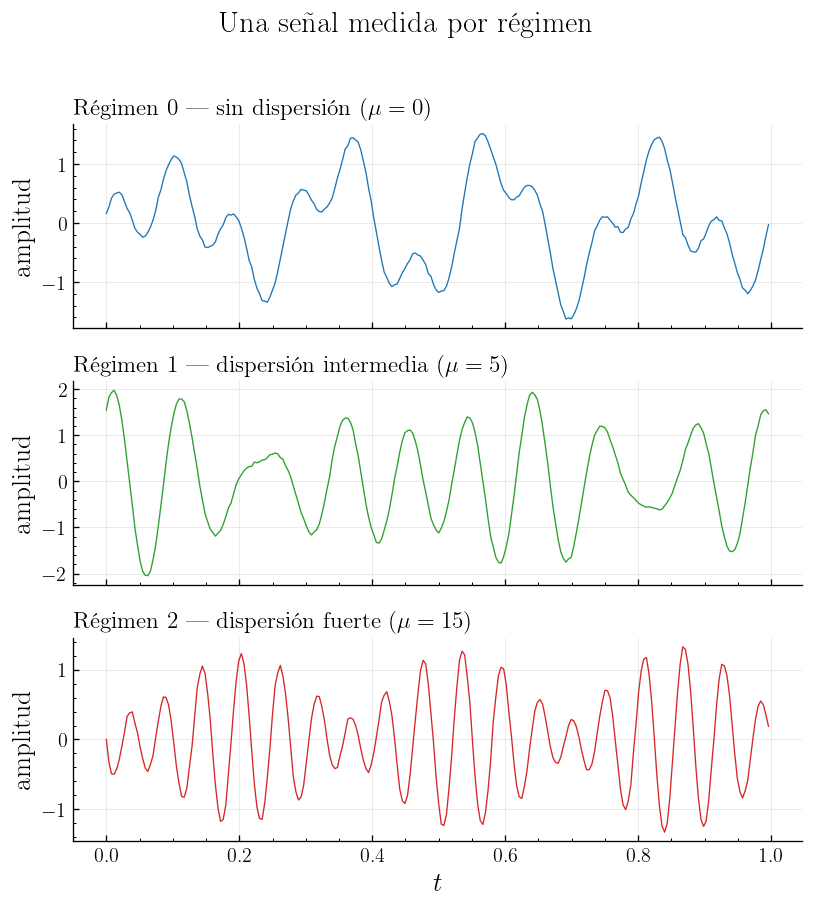

In [5]:
# ── Gráfica: una señal de ejemplo por régimen (estilo LaTeX) ──
titulos = {
    0: r"Régimen 0 --- sin dispersión ($\mu=0$)",
    1: r"Régimen 1 --- dispersión intermedia ($\mu=5$)",
    2: r"Régimen 2 --- dispersión fuerte ($\mu=15$)",
}

fig, axes = plt.subplots(3, 1, figsize=(7, 7.5), sharex=True)
for r, ax in zip([0, 1, 2], axes):
    x_ejemplo = X[y == r][0]
    ax.plot(t, x_ejemplo, color=COLOR_REGIMEN[r], lw=0.8)
    ax.set_title(titulos[r], fontsize=14, loc="left")
    ax.set_ylabel(r"amplitud")
    ax.grid(True, color="lightgray", linestyle="-", linewidth=0.4, alpha=0.7, zorder=0)

axes[-1].set_xlabel(r"$t$")
fig.suptitle(r"Una señal medida por régimen", y=1.01, fontsize=18)
fig.tight_layout()
plt.savefig("fig_senales_por_regimen.pdf")
plt.show()


## Parte III.1 — La capa Fourier (15 pts)

$W_1$ tiene $2K$ filas: las primeras $K$ son $\sin(2\pi k t)$ y las siguientes $K$ son $\cos(2\pi k t)$, para $k=1,\dots,K$.
Al multiplicar $W_1 x$ (antes de $\tanh$), cada fila calcula la proyección de $x$ sobre un seno o coseno de frecuencia $k$
— eso es, por definición, una transformada de Fourier en su versión seno/coseno (parte real/imaginaria de la DFT).

In [6]:
def build_fourier_layer(K, t):
    """Construye W1 (2K, len(t)): filas sin(2*pi*k*t) seguidas de cos(2*pi*k*t), k=1..K."""
    ks = jnp.arange(1, K + 1)
    S = jnp.sin(2 * jnp.pi * jnp.outer(ks, t))
    C = jnp.cos(2 * jnp.pi * jnp.outer(ks, t))
    return jnp.concatenate([S, C], axis=0)

W1_fourier = build_fourier_layer(K, jnp.array(t))
print("W1_fourier:", W1_fourier.shape)


W1_fourier: (50, 256)


**Verificación contra `np.fft`.** `np.fft.rfft` recibe **una** señal 1-D (256 muestras reales) y devuelve un vector
complejo con las componentes de frecuencia $k=0,\dots,128$: la parte real es la proyección sobre cosenos, la parte
imaginaria (con signo opuesto) es la proyección sobre senos. Actúa señal por señal — para el dataset completo hay que
aplicarlo fila por fila de `X` (o con `axis=1`, que internamente sigue siendo "una FFT por señal"). Comparamos, para
una señal, las proyecciones manuales de $W_1$ contra `np.fft.rfft`:

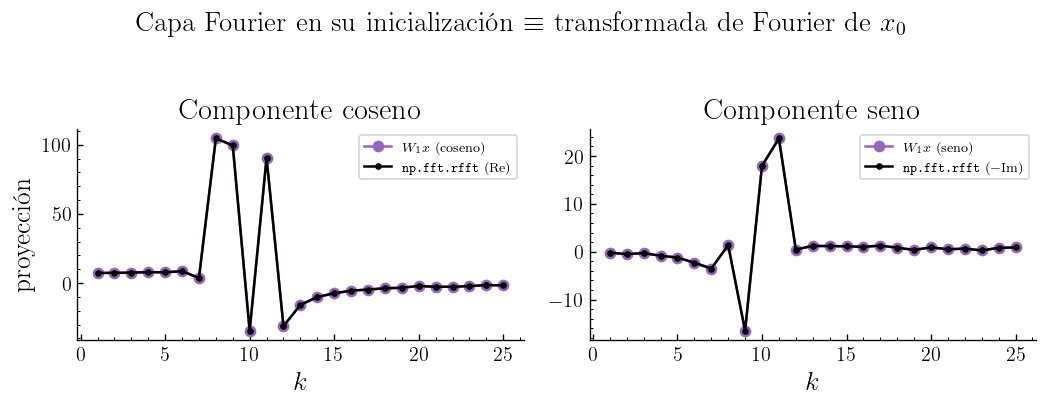

Discrepancia máxima W1 vs np.fft: 1.57e-04  (debe ser ~0)
Energía media del dataset (X**2).mean() = 0.742


In [7]:
x0 = X[0]
proyeccion = W1_fourier @ jnp.array(x0)
fft_np = np.fft.rfft(x0)

ks = np.arange(1, K + 1)
cos_manual = np.array(proyeccion[K:])
sin_manual = np.array(proyeccion[:K])
cos_fft = fft_np[1:K+1].real
sin_fft = -fft_np[1:K+1].imag

fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
axes[0].plot(ks, cos_manual, "o-", color="tab:purple", label=r"$W_1 x$ (coseno)")
axes[0].plot(ks, cos_fft, ".-", color="k", label=r"\texttt{np.fft.rfft} (Re)")
axes[0].set_xlabel(r"$k$"); axes[0].set_ylabel(r"proyección")
axes[0].set_title(r"Componente coseno"); axes[0].legend(fontsize=8)

axes[1].plot(ks, sin_manual, "o-", color="tab:purple", label=r"$W_1 x$ (seno)")
axes[1].plot(ks, sin_fft, ".-", color="k", label=r"\texttt{np.fft.rfft} ($-$Im)")
axes[1].set_xlabel(r"$k$")
axes[1].set_title(r"Componente seno"); axes[1].legend(fontsize=8)

fig.suptitle(r"Capa Fourier en su inicialización $\equiv$ transformada de Fourier de $x_0$", y=1.03)
fig.tight_layout()
plt.show()

error_max = np.max(np.abs(cos_manual - cos_fft)) + np.max(np.abs(sin_manual - sin_fft))
print(f"Discrepancia máxima W1 vs np.fft: {error_max:.2e}  (debe ser ~0)")

energia_media = float((X**2).mean())
print(f"Energía media del dataset (X**2).mean() = {energia_media:.3f}")
